# ---------------------------------------------------------------
# Da'wah Bot - Phase 1: Single-Column Analyses
# Cell markers use the `# %%` convention (VS Code / PyCharm / Jupytext).
# Copy each block between markers into its own notebook cell.
# `# %% [markdown]` blocks are markdown cells; the rest are code cells.
# ---------------------------------------------------------------

# %% [markdown]
# # Da'wah Bot — Phase 1: Single-Column Analyses
#
# Simple, high-value analyses using **one column at a time** (Python only).
#
# **Structure per analysis:** a title/explanation cell → a main analysis cell (prints numbers, then draws the graph) → an optional-pairing cell (same style).
#
# Run **Step 0** first; it loads the data, cleans it, and defines the helper functions every analysis below relies on.


## Step 0 — Setup, data prep & helper functions

Loads the data and does the light cleaning we agreed on:
- unifies blanks / `"N/A"` into one `Not Applicable` marker,
- trims whitespace and standardizes a few category spellings (e.g. `Central Kurdish` → `Kurdish`),
- forces the right data types (scores → integers, flags → true/false).

It also defines small helpers so each analysis cell stays short and readable.
**Change `FILE_PATH`** to point at your full 12,000-row file.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display  # optional rich display

# --- Make tables print in FULL (no truncated middle rows/columns) so results copy completely ---
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", None)

def show(obj, label=None):
    """Print a table in FULL as plain text (nothing truncated) -- copy-paste friendly."""
    if label:
        print(label)
    frame = obj.to_frame() if isinstance(obj, pd.Series) else obj
    print(frame.to_string())
    print()

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# >>> CHANGE THIS to your full dataset path <<<
FILE_PATH = "full_conversation_points_extraction.csv"

df = pd.read_csv(FILE_PATH)

# ---- cleaning ----
NA_LABEL  = "Not Applicable"
NA_TOKENS = {"n/a", "na", "none", "null", "", "not applicable"}

def clean_cat(series):
    """Trim text and turn any 'not applicable' style value into a real missing value."""
    s = series.astype("string").str.strip()
    return s.mask(s.str.lower().isin(NA_TOKENS))

CAT_COLS = ["suspected_religion", "user_language", "conversation_type", "engagement_flow",
            "key_blocker", "start_mood", "end_mood", "user_intent", "conversion_funnel"]
for c in CAT_COLS:
    df[c] = clean_cat(df[c])

def to_bool(series):
    if series.dtype == bool:
        return series
    return (series.astype("string").str.strip().str.lower()
            .map({"true": True, "false": False, "1": True, "0": False,
                  "yes": True, "no": False}))

df["is_existing_muslim"] = to_bool(df["is_existing_muslim"])
df["script_dumping"]     = to_bool(df["script_dumping"])
df["engagement_score"]   = pd.to_numeric(df["engagement_score"], errors="coerce").astype("Int64")
df["response_quality"]   = pd.to_numeric(df["response_quality"], errors="coerce").astype("Int64")

# standardize a few language spelling variants (extend this dict as needed at full scale)
df["user_language"] = df["user_language"].replace({"Central Kurdish": "Kurdish",
                                                   "Kurdish (Central)": "Kurdish"})

print(f"Loaded {len(df):,} conversations, {df.shape[1]} columns.")

# ---------- helper functions ----------
def cat_summary(series):
    """Return a count + percent table for one column (missing values dropped)."""
    s = series.dropna()
    counts = s.value_counts()
    pct = (counts / len(s) * 100).round(1)
    out = pd.DataFrame({"count": counts, "percent": pct})
    out.index.name = series.name
    return out

# def plot_bar(summary, title, ylabel="Number of conversations",
#              horizontal=False, color="#2c7fb8"):
#     """Bar chart from a cat_summary() table, with % labels on the bars."""
#     fig, ax = plt.subplots()
#     idx = [str(i) for i in summary.index]
#     if horizontal:
#         y = range(len(summary))[::-1]
#         ax.barh(y, summary["count"].values, color=color)
#         ax.set_yticks(list(y)); ax.set_yticklabels(idx)
#         ax.set_xlabel(ylabel)
#         for yi, (n, p) in zip(y, zip(summary["count"], summary["percent"])):
#             ax.text(n, yi, f" {p}%", va="center", fontsize=9)
#     else:
#         x = range(len(summary))
#         ax.bar(x, summary["count"].values, color=color)
#         ax.set_xticks(list(x)); ax.set_xticklabels(idx, rotation=45, ha="right")
#         ax.set_ylabel(ylabel)
#         for xi, n, p in zip(x, summary["count"], summary["percent"]):
#             ax.text(xi, n, f"{p}%", ha="center", va="bottom", fontsize=9)
#     ax.set_title(title, fontsize=12, fontweight="bold")
#     plt.tight_layout(); plt.show()

# def plot_crosstab(ct, title, stacked=True, ylabel="Number of conversations"):
#     """Grouped/stacked bar from a crosstab (two categorical columns)."""
#     ax = ct.plot(kind="bar", stacked=stacked, colormap="viridis")
#     ax.set_title(title, fontsize=12, fontweight="bold")
#     ax.set_ylabel(ylabel); plt.xticks(rotation=45, ha="right")
#     ax.legend(title=ct.columns.name, bbox_to_anchor=(1.02, 1), loc="upper left")
#     plt.tight_layout(); plt.show()

# def plot_mean_bar(grouped, title, ylabel, color="#d95f0e", baseline=None):
#     """Bar chart of average values per category (e.g. avg quality per language)."""
#     fig, ax = plt.subplots()
#     idx = [str(i) for i in grouped.index]
#     x = range(len(grouped))
#     ax.bar(x, grouped.values.astype(float), color=color)
#     ax.set_xticks(list(x)); ax.set_xticklabels(idx, rotation=45, ha="right")
#     ax.set_ylabel(ylabel)
#     for xi, v in zip(x, grouped.values.astype(float)):
#         ax.text(xi, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
#     if baseline is not None:
#         ax.axhline(baseline, color="grey", ls="--", lw=1, label=f"overall avg = {baseline:.2f}")
#         ax.legend()
#     ax.set_title(title, fontsize=12, fontweight="bold")
#     plt.tight_layout(); plt.show()

# def plot_heatmap(ct, title):
#     """Annotated heatmap from a crosstab of two categorical columns."""
#     fig, ax = plt.subplots(figsize=(max(6, ct.shape[1]*1.1), max(4, ct.shape[0]*0.6)))
#     im = ax.imshow(ct.values, cmap="Blues", aspect="auto")
#     ax.set_xticks(range(ct.shape[1])); ax.set_xticklabels(ct.columns, rotation=45, ha="right")
#     ax.set_yticks(range(ct.shape[0])); ax.set_yticklabels(ct.index)
#     for i in range(ct.shape[0]):
#         for j in range(ct.shape[1]):
#             v = ct.values[i, j]
#             ax.text(j, i, int(v), ha="center", va="center",
#                     color="white" if v > ct.values.max()/2 else "black", fontsize=9)
#     ax.set_title(title, fontsize=12, fontweight="bold")
#     ax.set_xlabel(ct.columns.name); ax.set_ylabel(ct.index.name)
#     fig.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout(); plt.show()
def plot_bar(summary, title, ylabel="Number of conversations",
             horizontal=False, color="#2c7fb8", top_n=None):
    """top_n: if set, the CHART shows only the first N rows (the largest, since the
    table is count-sorted). The printed table is not affected."""
    if top_n is not None and len(summary) > top_n:
        title = f"{title} (top {top_n} of {len(summary)})"
        summary = summary.head(top_n)
    fig, ax = plt.subplots()
    idx = [str(i) for i in summary.index]
    if horizontal:
        y = range(len(summary))[::-1]
        ax.barh(y, summary["count"].values, color=color)
        ax.set_yticks(list(y)); ax.set_yticklabels(idx)
        ax.set_xlabel(ylabel)
        for yi, (n, p) in zip(y, zip(summary["count"], summary["percent"])):
            ax.text(n, yi, f" {p}%", va="center", fontsize=9)
    else:
        x = range(len(summary))
        ax.bar(x, summary["count"].values, color=color)
        ax.set_xticks(list(x)); ax.set_xticklabels(idx, rotation=45, ha="right")
        ax.set_ylabel(ylabel)
        for xi, n, p in zip(x, summary["count"], summary["percent"]):
            ax.text(xi, n, f"{p}%", ha="center", va="bottom", fontsize=9)
    ax.set_title(title, fontsize=12, fontweight="bold")
    plt.tight_layout(); plt.show()


def plot_crosstab(ct, title, stacked=True, ylabel="Number of conversations", top_n=None):
    """top_n: keep only the N categories (rows) with the highest total count."""
    if top_n is not None and len(ct) > top_n:
        title = f"{title} (top {top_n} of {len(ct)})"
        ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).head(top_n).index]
    ax = ct.plot(kind="bar", stacked=stacked, colormap="viridis")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel); plt.xticks(rotation=45, ha="right")
    ax.legend(title=ct.columns.name, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout(); plt.show()


def plot_mean_bar(grouped, title, ylabel, color="#d95f0e", baseline=None, top_n=None):
    """top_n: if set, the CHART shows only the first N entries of the (already-sorted)
    series. The printed table is not affected."""
    if top_n is not None and len(grouped) > top_n:
        title = f"{title} (top {top_n} of {len(grouped)})"
        grouped = grouped.head(top_n)
    fig, ax = plt.subplots()
    idx = [str(i) for i in grouped.index]
    x = range(len(grouped))
    ax.bar(x, grouped.values.astype(float), color=color)
    ax.set_xticks(list(x)); ax.set_xticklabels(idx, rotation=45, ha="right")
    ax.set_ylabel(ylabel)
    for xi, v in zip(x, grouped.values.astype(float)):
        ax.text(xi, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    if baseline is not None:
        ax.axhline(baseline, color="grey", ls="--", lw=1, label=f"overall avg = {baseline:.2f}")
        ax.legend()
    ax.set_title(title, fontsize=12, fontweight="bold")
    plt.tight_layout(); plt.show()


def plot_heatmap(ct, title, top_n=None):
    """top_n: keep only the N categories (rows) with the highest total count."""
    if top_n is not None and len(ct) > top_n:
        title = f"{title} (top {top_n} of {len(ct)})"
        ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).head(top_n).index]
    fig, ax = plt.subplots(figsize=(max(6, ct.shape[1]*1.1), max(4, ct.shape[0]*0.6)))
    im = ax.imshow(ct.values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(ct.shape[1])); ax.set_xticklabels(ct.columns, rotation=45, ha="right")
    ax.set_yticks(range(ct.shape[0])); ax.set_yticklabels(ct.index)
    for i in range(ct.shape[0]):
        for j in range(ct.shape[1]):
            v = ct.values[i, j]
            ax.text(j, i, int(v), ha="center", va="center",
                    color="white" if v > ct.values.max()/2 else "black", fontsize=9)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(ct.columns.name); ax.set_ylabel(ct.index.name)
    fig.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout(); plt.show()
print("Setup complete — helpers ready.")

Loaded 12,448 conversations, 39 columns.
Setup complete — helpers ready.


## 1. `suspected_religion` — Who is the bot reaching?

**Measures:** the share of conversations from each religious background.
**Why it matters:** the whole da'wah strategy depends on who actually shows up. A large "Unknown" share means the bot often fails to learn who it's talking to; a large "Islam" share means effort spent on non-prospects; a dominant group (e.g. Christianity) tells you where your content must be strongest.
**Pairing (`× is_existing_muslim`):** cross-checks the data and cleanly separates non-Muslim prospects from existing Muslims.


User religion distribution:
                    count  percent
suspected_religion                
Islam                4552     36.6
Unknown              4411     35.4
Christianity         2036     16.4
Atheism               671      5.4
Hinduism              212      1.7
Agnosticism           161      1.3
Irreligion            107      0.9
Other                 104      0.8
Buddhism              103      0.8
Judaism                88      0.7
Sikhism                 2      0.0
ERROR                   1      0.0



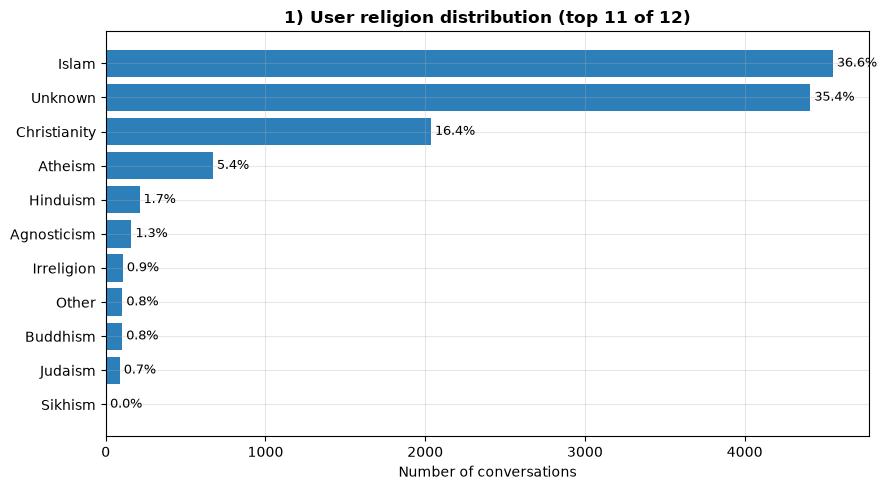

In [47]:
# %%
# --- Main: religion distribution ---
summary = cat_summary(df["suspected_religion"])
print("User religion distribution:")
show(summary)
plot_bar(summary, "1) User religion distribution", horizontal=True,top_n=11)


Religion split by Muslim / Non-Muslim:
user                Muslim  Non-Muslim
suspected_religion                    
Agnosticism              1         160
Atheism                  0         671
Buddhism                 0         103
Christianity             3        2033
ERROR                    0           1
Hinduism                 2         210
Irreligion               1         106
Islam                 4552           0
Judaism                  0          88
Other                    2         102
Sikhism                  0           2
Unknown                 40        4371



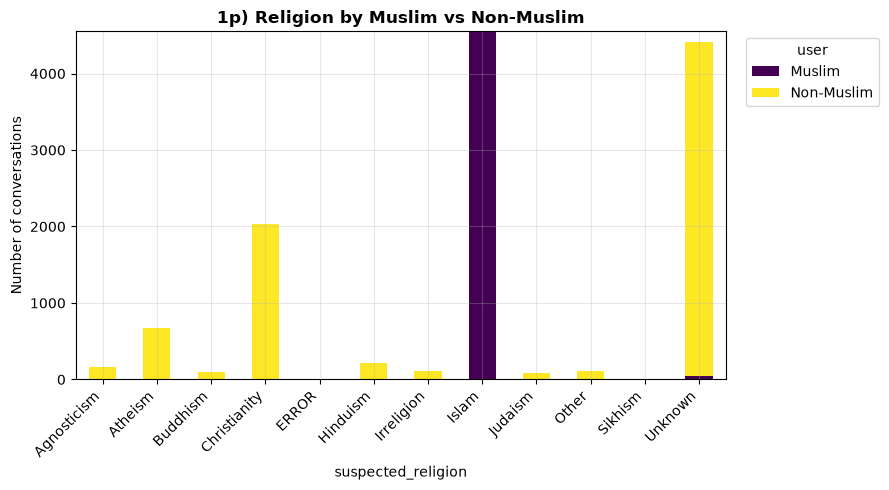

In [15]:
# --- Pairing: religion x is_existing_muslim ---
ct = pd.crosstab(df["suspected_religion"],
                 df["is_existing_muslim"].map({True: "Muslim", False: "Non-Muslim"}))
ct.columns.name = "user"
print("Religion split by Muslim / Non-Muslim:")
show(ct)
plot_crosstab(ct, "1p) Religion by Muslim vs Non-Muslim", stacked=True)

## 2. `is_existing_muslim` — Prospects vs. non-target traffic

**Measures:** how much traffic is already Muslim vs. non-Muslim.
**Why it matters:** the bot exists for da'wah to *non-Muslims*. A big Muslim share is "off-mission" traffic and raises a real decision: does the org need a separate assistant for Muslims so the da'wah bot can focus?
**Pairing (`× conversation_type`):** shows *what* Muslim users actually come for — i.e. what a future Muslim assistant would need to handle.


Existing Muslim vs Non-Muslim:
            count  percent
audience                  
Non-Muslim   7847     63.0
Muslim       4601     37.0



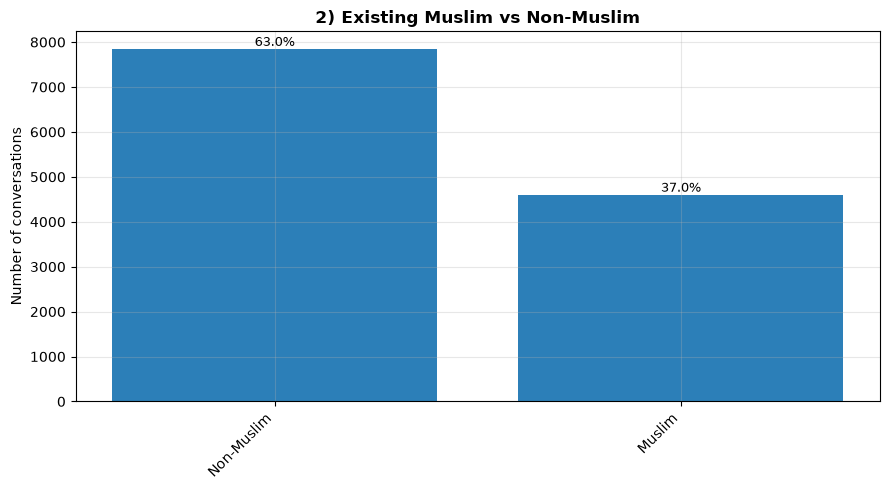

In [16]:

# %%
# --- Main: Muslim vs Non-Muslim ---
labels = df["is_existing_muslim"].map({True: "Muslim", False: "Non-Muslim"})
summary = cat_summary(labels.rename("audience"))
print("Existing Muslim vs Non-Muslim:")
show(summary)
plot_bar(summary, "2) Existing Muslim vs Non-Muslim")


Conversation types among 4601 Muslim users:
                       count  percent
conversation_type                    
Islamic Guidance        2690     58.5
Dawah Training           838     18.2
Minimal/No Engagement    537     11.7
Off-Topic                311      6.8
Content Assistance       117      2.5
Theological Debate        37      0.8
Dawah                     34      0.7
Emotional Support         29      0.6
Muslim Learner             8      0.2



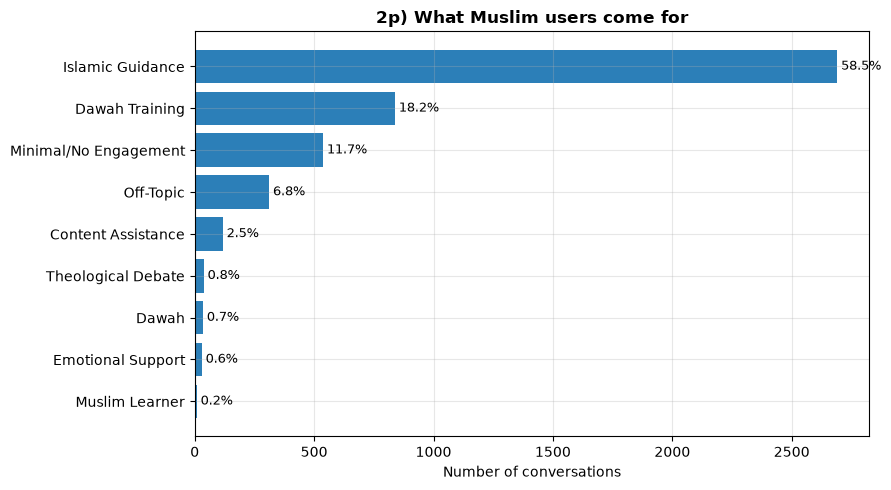

In [17]:
# --- Pairing: what Muslim users come for ---
muslims = df[df["is_existing_muslim"] == True]
summary = cat_summary(muslims["conversation_type"])
print(f"Conversation types among {len(muslims)} Muslim users:")
show(summary)
plot_bar(summary, "2p) What Muslim users come for", horizontal=True)

## 3. `user_language` — Reach and gaps

**Measures:** how many conversations happen in each language the user writes in.
**Why it matters:** language = geographic and cultural reach. Dominant languages deserve the most quality attention; a surprising long tail (Japanese, Amharic…) signals organic demand you could serve intentionally.
**Pairing (`× response_quality`):** average bot quality per language — high volume + low quality = a clear localization problem.


User language distribution:
                     count  percent
user_language                      
Arabic                5709     45.9
English               4274     34.3
Swahili                613      4.9
Japanese               355      2.9
French                 302      2.4
Kurdish                194      1.6
Tagalog                158      1.3
Korean                 121      1.0
Spanish                 96      0.8
Urdu                    93      0.7
Chinese                 71      0.6
German                  51      0.4
Hindi                   43      0.3
Portuguese              39      0.3
Turkish                 39      0.3
Unknown                 36      0.3
Filipino                35      0.3
Russian                 22      0.2
Tamil                   18      0.1
Khmer                   17      0.1
Sinhala                 16      0.1
Dutch                   10      0.1
Malay                   10      0.1
Kinyarwanda             10      0.1
Swedish                  9      0.1


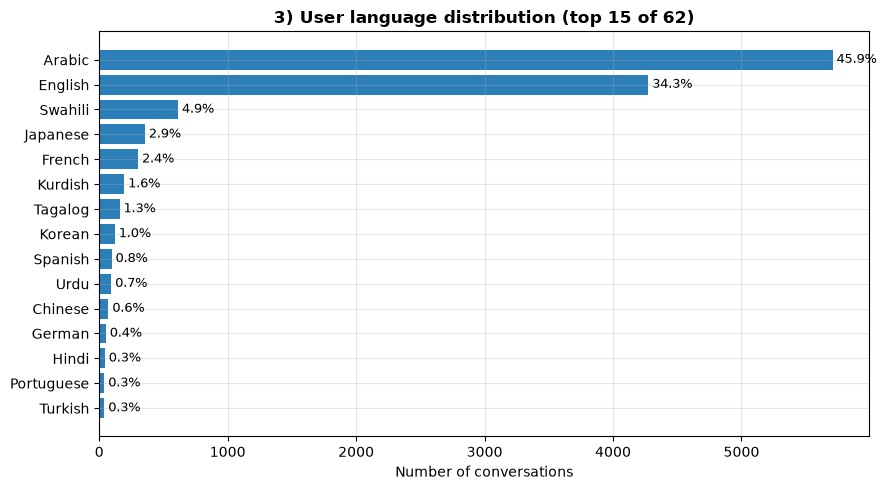

In [38]:

# %%
# --- Main: language distribution ---
summary = cat_summary(df["user_language"])
print("User language distribution:")
show(summary)
plot_bar(summary, "3) User language distribution", horizontal=True, top_n=15)


Average response quality by language (with volume):
                     avg_quality     n
user_language                         
Arabic                      3.05  5709
English                     2.92  4274
Swahili                     3.91   613
Japanese                     3.5   355
French                      2.96   302
Kurdish                     2.71   194
Tagalog                     3.42   158
Korean                      3.52   121
Spanish                     2.79    96
Urdu                        2.99    93
Chinese                     2.51    71
German                      2.84    51
Hindi                       3.12    43
Portuguese                  2.56    39
Turkish                     3.03    39
Unknown                     2.47    36
Filipino                    3.31    35
Russian                     3.05    22
Tamil                        2.5    18
Khmer                       2.53    17
Sinhala                     2.19    16
Malay                        2.8    10
Dutch       

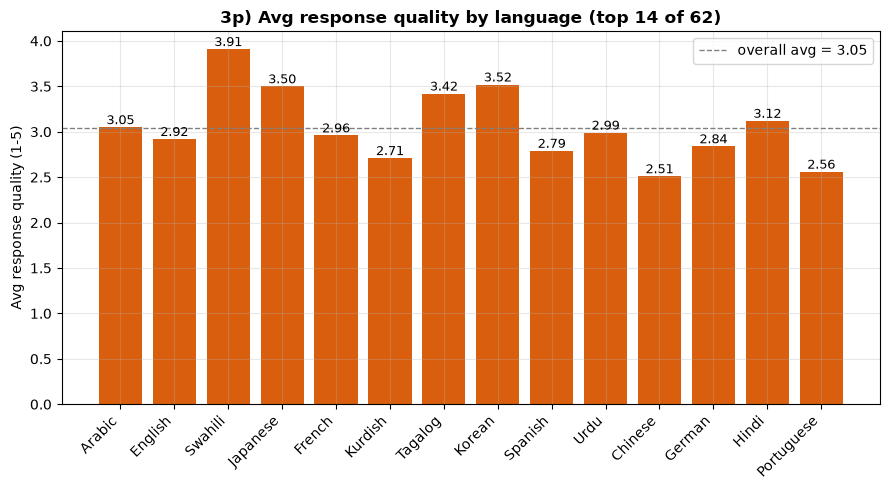

In [39]:


# %%
# --- Pairing: avg response quality per language ---
g = (df.dropna(subset=["user_language", "response_quality"])
       .groupby("user_language")["response_quality"]
       .agg(avg_quality="mean", n="count").round(2)
       .sort_values("n", ascending=False))
print("Average response quality by language (with volume):")
show(g)
overall = df["response_quality"].mean()
plot_mean_bar(g["avg_quality"], "3p) Avg response quality by language",
              "Avg response quality (1-5)", baseline=overall, top_n=14)

%% [markdown]
## 4. `conversation_type` — Is the bot doing its job?

**Measures:** what the bot is actually used for (Dawah, Debate, Guidance, Off-Topic, Minimal…).
**Why it matters:** reveals mission-aligned use vs. noise vs. misuse. A big "Minimal/No Engagement" slice warns that lots of traffic never becomes a real conversation.
**Pairing (`× engagement_score`):** which types actually produce deep engagement.


Conversation type distribution:
                       count  percent
conversation_type                    
Dawah                   3419     27.5
Minimal/No Engagement   2834     22.8
Islamic Guidance        2814     22.6
Theological Debate      1354     10.9
Dawah Training           912      7.3
Off-Topic                783      6.3
Content Assistance       269      2.2
Emotional Support         54      0.4
Muslim Learner             8      0.1
ERROR                      1      0.0



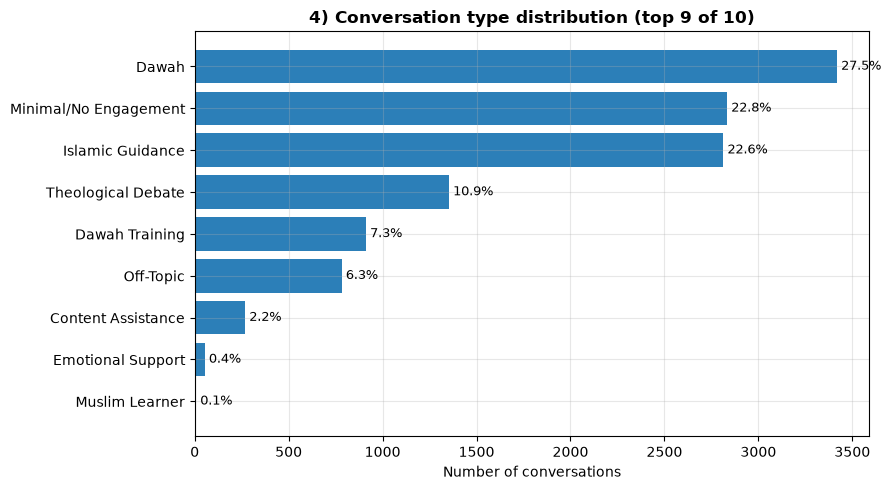

In [49]:

# %%
# --- Main: conversation type distribution ---
summary = cat_summary(df["conversation_type"])
print("Conversation type distribution:")
show(summary)
plot_bar(summary, "4) Conversation type distribution", horizontal=True,top_n=9)


Average engagement score by conversation type:
                       avg_engagement     n
conversation_type                          
Muslim Learner                   4.38     8
Theological Debate               3.68  1354
Dawah Training                   3.35   912
Islamic Guidance                 2.81  2814
Emotional Support                2.63    54
Content Assistance               2.23   269
Dawah                            2.21  3419
Off-Topic                        1.78   783
Minimal/No Engagement            1.05  2834
ERROR                             0.0     1



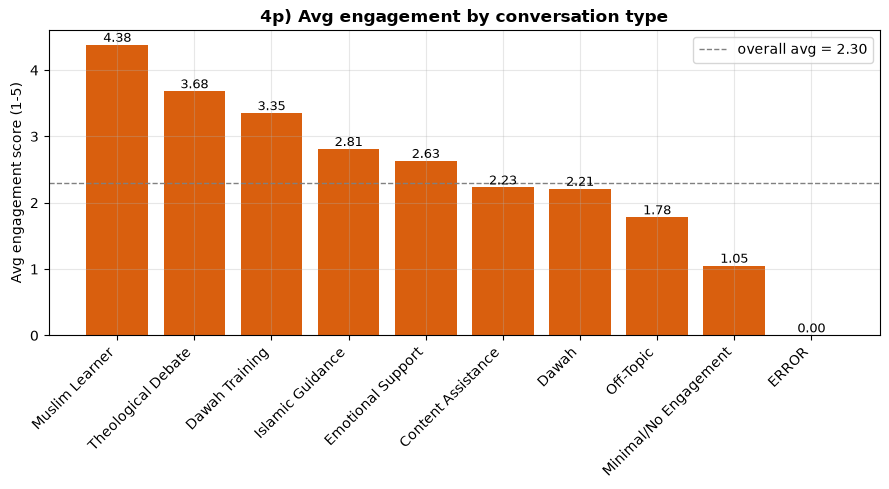

In [41]:
# --- Pairing: avg engagement per conversation type ---
g = (df.dropna(subset=["conversation_type", "engagement_score"])
       .groupby("conversation_type")["engagement_score"]
       .agg(avg_engagement="mean", n="count").round(2)
       .sort_values("avg_engagement", ascending=False))
print("Average engagement score by conversation type:")
show(g)
plot_mean_bar(g["avg_engagement"], "4p) Avg engagement by conversation type",
              "Avg engagement score (1-5)", baseline=df["engagement_score"].mean())
 


## 5. `engagement_score` — Are users really engaging?

**Measures:** distribution of scores 1 (no interaction) → 5 (deep), plus average & median.
**Why it matters:** the best "real conversation?" metric, designed to *not* be fooled by a chatty bot. Lots of 1s and 2s = users are passive no matter how much the bot preaches.
**Pairing (`× engagement_flow`):** do high scores come with *balanced* conversations (ideal) and low scores with bot-domination (the problem)?


Engagement score distribution:
                  count  percent
engagement_score                
0                     1      0.0
1                  5595     44.9
2                  1752     14.1
3                  1794     14.4
4                  2379     19.1
5                   927      7.4

Average = 2.30 | Median = 2.0


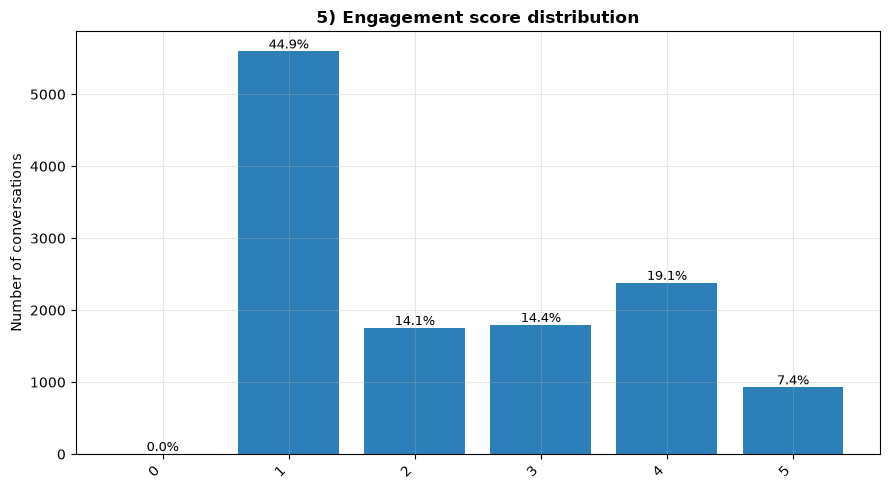

In [21]:
# %%
# --- Main: engagement score distribution ---
summary = cat_summary(df["engagement_score"]).sort_index()
print("Engagement score distribution:")
show(summary)
print(f"Average = {df['engagement_score'].mean():.2f} | Median = {df['engagement_score'].median():.1f}")
plot_bar(summary, "5) Engagement score distribution")


Engagement score by conversation flow:
flow              Balanced  Bot-Dominated  ERROR  User-Dominated
engagement_score                                                
0                        0              0      1               0
1                        1           5553      0              41
2                        1           1747      0               4
3                      262           1500      0              32
4                     1236           1062      0              81
5                      873             14      0              40



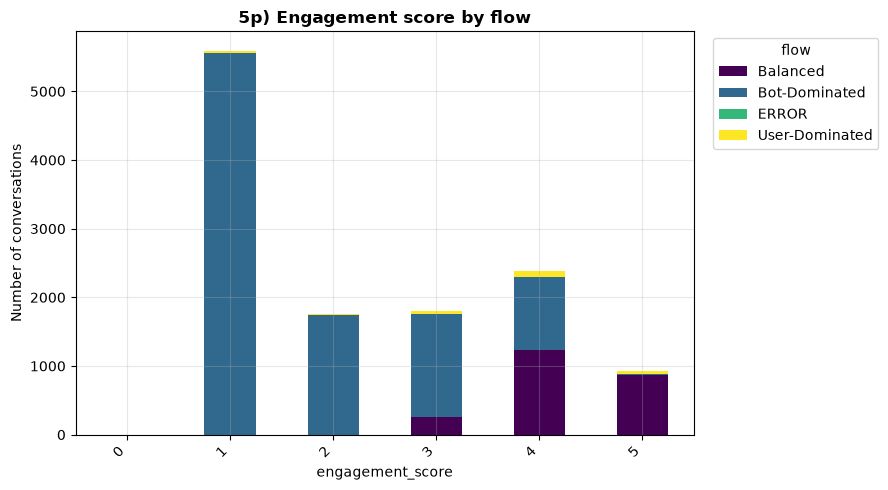

In [22]:
# %%
# --- Pairing: engagement score x flow ---
ct = pd.crosstab(df["engagement_score"], df["engagement_flow"])
ct.columns.name = "flow"
print("Engagement score by conversation flow:")
show(ct)
plot_crosstab(ct, "5p) Engagement score by flow", stacked=True)



## 6. `engagement_flow` — Is the bot dominating?

**Measures:** share of Bot-Dominated vs. Balanced vs. User-Dominated conversations.
**Why it matters:** good da'wah is dialogue, not a lecture. A high "Bot-Dominated" share suggests the bot broadcasts instead of listening — a style problem that pushes users away.
**Pairing (`× engagement_score`):** tests whether balanced conversations really score higher (a strong argument for a less talkative bot).


Engagement flow distribution:
                 count  percent
engagement_flow                
Bot-Dominated     9876     79.3
Balanced          2373     19.1
User-Dominated     198      1.6
ERROR                1      0.0



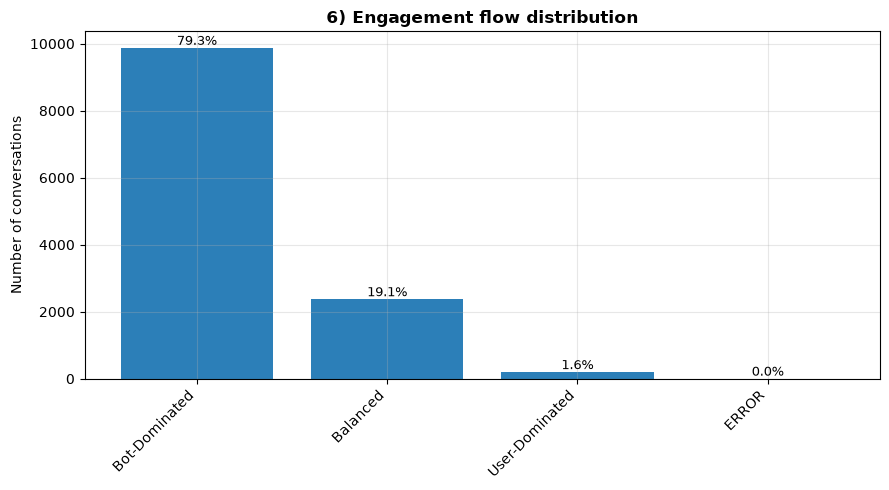

In [23]:

# %%
# --- Main: engagement flow distribution ---
summary = cat_summary(df["engagement_flow"])
print("Engagement flow distribution:")
show(summary)
plot_bar(summary, "6) Engagement flow distribution")

Average engagement score by flow:
                 avg_engagement     n
engagement_flow                      
Balanced                   4.26  2373
User-Dominated             3.38   198
Bot-Dominated              1.81  9876
ERROR                       0.0     1



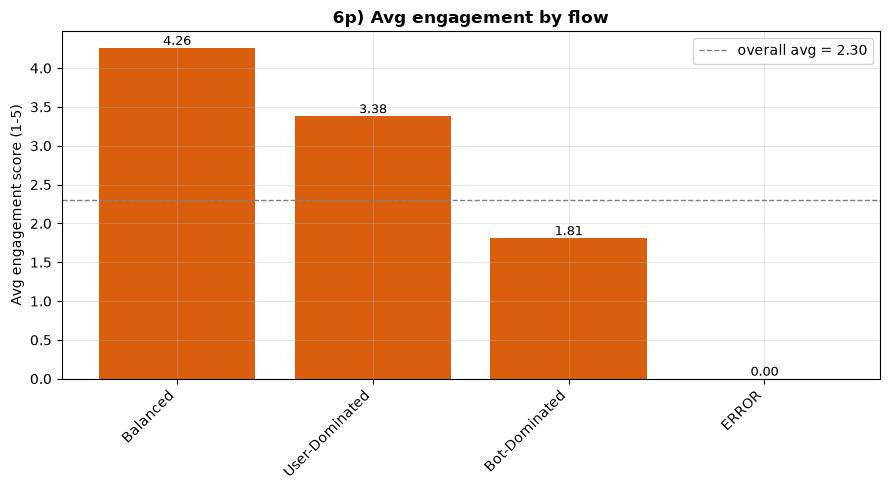

In [24]:
# %%
# --- Pairing: avg score per flow ---
g = (df.dropna(subset=["engagement_flow", "engagement_score"])
       .groupby("engagement_flow")["engagement_score"]
       .agg(avg_engagement="mean", n="count").round(2)
       .sort_values("avg_engagement", ascending=False))
print("Average engagement score by flow:")
show(g)
plot_mean_bar(g["avg_engagement"], "6p) Avg engagement by flow",
              "Avg engagement score (1-5)", baseline=df["engagement_score"].mean())


## 7. `key_blocker` — What stops people from accepting Islam?

**Measures:** among conversations that *have* a blocker (Not-Applicable rows excluded), the frequency of each barrier.
**Why it matters:** one of the most actionable columns — a ranked priority list for content and da'wah training. Many rows are blank (Muslims / no resistance); analyze only rows with a real blocker.
**Pairing (`× suspected_religion`):** which barrier belongs to which group (Christians → Trinity, Atheists → Logical Skepticism), turning the list into a targeted playbook.


Key blockers among 3443 conversations that had one (9005 rows were Not Applicable):
                                                       count  percent
key_blocker                                                          
Logical Skepticism                                      1185     34.4
Lack of Interest                                        1041     30.2
Trinity                                                  456     13.2
Moral Objection                                          224      6.5
Atheism                                                  174      5.1
Cultural Identity                                        126      3.7
Negative Media Perception                                117      3.4
Sectarian Confusion                                       60      1.7
Family Pressure                                           23      0.7
Distrust of Religion                                      17      0.5
Language barrier                                           2      0.1
Indivi

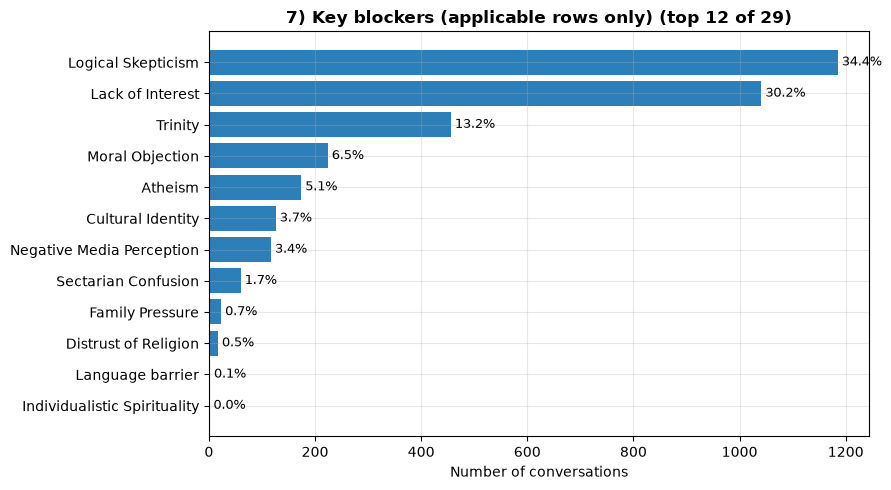

In [42]:
# %%
# --- Main: key blocker distribution (applicable rows only) ---
blockers = df["key_blocker"].dropna()
summary = cat_summary(blockers)
print(f"Key blockers among {len(blockers)} conversations that had one "
      f"({len(df)-len(blockers)} rows were Not Applicable):")
show(summary)
plot_bar(summary, "7) Key blockers (applicable rows only)", horizontal=True,top_n=12)


Key blocker by religion:
suspected_religion                                     Agnosticism  Atheism  Buddhism  Christianity  ERROR  Hinduism  Irreligion  Islam  Judaism  Other  Sikhism  Unknown
key_blocker                                                                                                                                                              
Atheism                                                          0      169         2             0      0         1           2      0        0      0        0        0
Christianity                                                     0        0         0             1      0         0           0      0        0      0        0        0
Cultural Identity                                                3        6         3            63      0        28           3      2        6      6        1        5
Distrust of Religion                                             3        3         0             3      0         0         

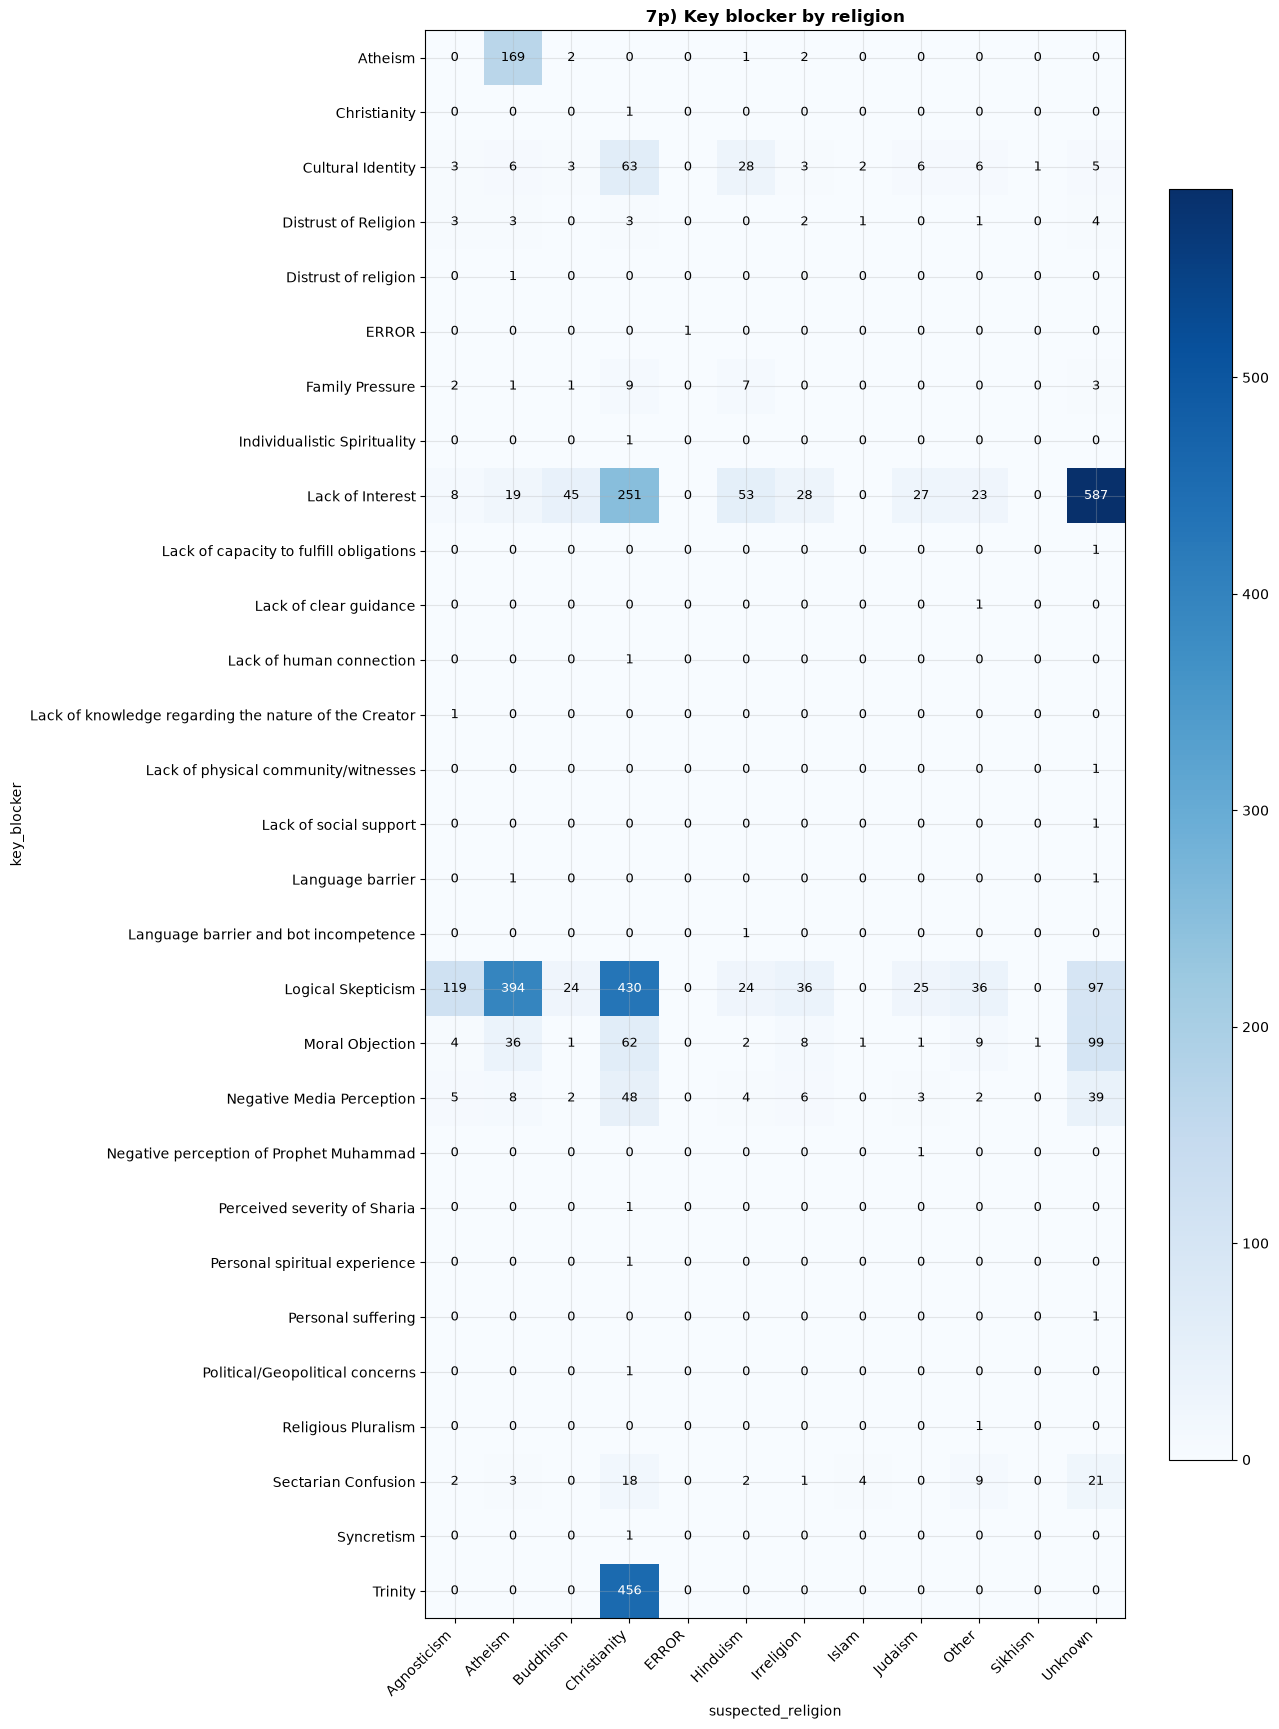

In [26]:
# %%
# --- Pairing: blocker x religion ---
ct = pd.crosstab(df["key_blocker"], df["suspected_religion"])
print("Key blocker by religion:")
show(ct)
plot_heatmap(ct, "7p) Key blocker by religion")


## 8. `start_mood` — What state do users arrive in?

**Measures:** the user's opening mood (Neutral, Curious, Skeptical, Hostile…).
**Why it matters:** the entry mood should shape the bot's first message. Mostly-Neutral arrivals mean a calm open door the bot shouldn't waste with a rigid questionnaire; many Skeptical/Hostile arrivals mean the opening must build trust first.
**Pairing (`× conversation_type`):** e.g. do debaters arrive skeptical while guidance-seekers arrive neutral?


Start mood distribution:
              count  percent
start_mood                  
Neutral       10435     83.8
Curious         606      4.9
Skeptical       580      4.7
Confident       166      1.3
Distressed      154      1.2
Reverent        136      1.1
Hostile         126      1.0
Respectful       61      0.5
Anxious          54      0.4
Playful          44      0.4
Enthusiastic     39      0.3
Confused         36      0.3
Frustrated        6      0.0
Friendly          1      0.0
Critical          1      0.0
Grateful          1      0.0
ERROR             1      0.0
Conflicted        1      0.0



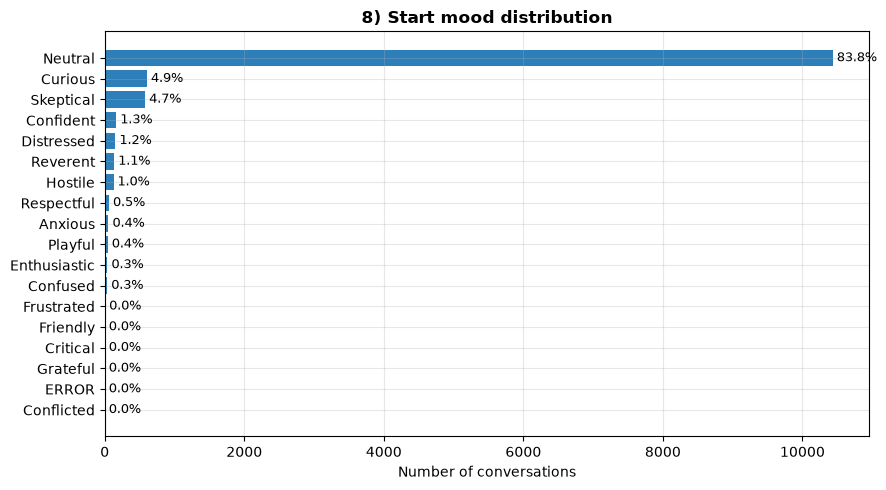

In [27]:

# %%
# --- Main: start mood distribution ---
summary = cat_summary(df["start_mood"])
print("Start mood distribution:")
show(summary)
plot_bar(summary, "8) Start mood distribution", horizontal=True)


Start mood by conversation type:
conversation_type  Content Assistance  Dawah  Dawah Training  ERROR  Emotional Support  Islamic Guidance  Minimal/No Engagement  Muslim Learner  Off-Topic  Theological Debate
start_mood                                                                                                                                                                    
Anxious                             0      8               3      0                  5                36                      0               0          2                   0
Confident                           0     24              12      0                  0                16                      1               0          1                 112
Conflicted                          0      0               0      0                  0                 1                      0               0          0                   0
Confused                            0     15               1      0                  0      

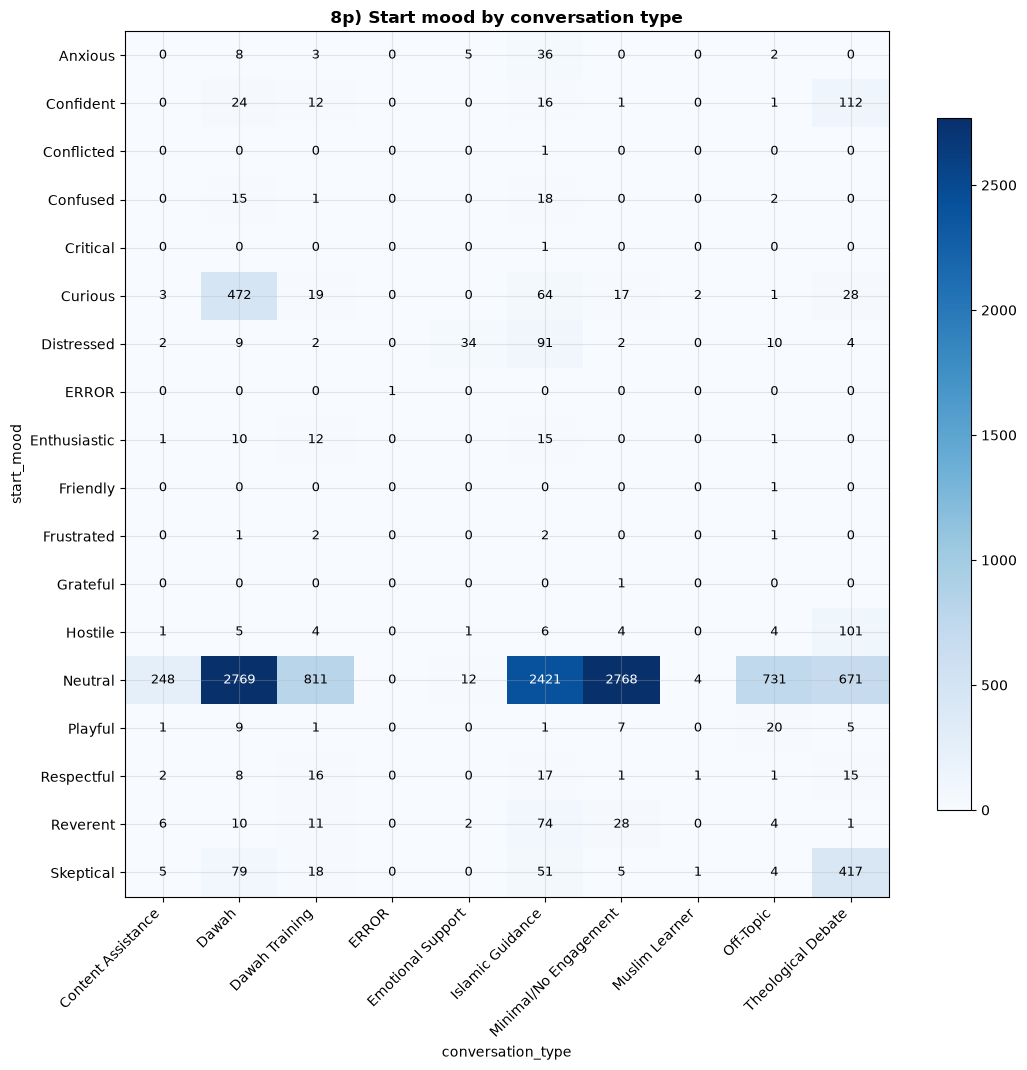

In [28]:

# %%
# --- Pairing: start mood x conversation type ---
ct = pd.crosstab(df["start_mood"], df["conversation_type"])
print("Start mood by conversation type:")
show(ct)
plot_heatmap(ct, "8p) Start mood by conversation type")



## 9. `end_mood` — How do users leave?

**Measures:** the user's final mood, with the **ghost rate** (left and never came back) called out.
**Why it matters:** the closest thing to an outcome per conversation. A high ghost rate is a loud signal the experience loses people; the positive-exit share (Informed/Satisfied/Grateful) is your win count.
**Pairing (`× script_dumping`):** a first look at whether the bot's script-dumping habit is linked to people leaving.


End mood distribution:
              count  percent
end_mood                    
Ghosted        7391     59.4
Neutral        1734     13.9
Satisfied       880      7.1
Skeptical       421      3.4
Informed        403      3.2
Engaged         391      3.1
Frustrated      291      2.3
Grateful        272      2.2
Receptive       240      1.9
Inspired        160      1.3
Indifferent      73      0.6
Comforted        50      0.4
Confident        38      0.3
Distressed       23      0.2
Hostile          18      0.1
Curious          17      0.1
Reverent          9      0.1
Confused          9      0.1
Playful           8      0.1
Anxious           7      0.1
Overwhelmed       5      0.0
Enthusiastic      3      0.0
Respectful        3      0.0
Inquisitive       1      0.0
ERROR             1      0.0

GHOST RATE = 59.4% of conversations ended in the user disappearing.


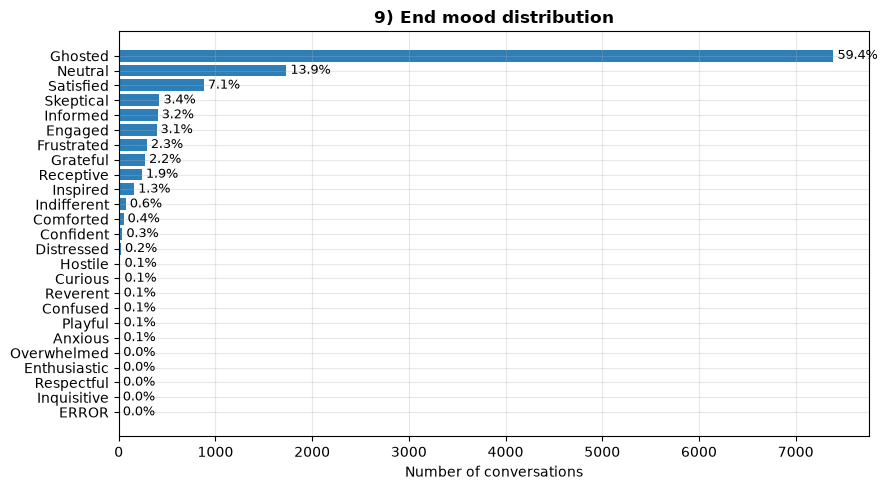

In [29]:
# %%
# --- Main: end mood distribution + ghost rate ---
summary = cat_summary(df["end_mood"])
print("End mood distribution:")
show(summary)
ghost_rate = (df["end_mood"] == "Ghosted").mean() * 100
print(f"GHOST RATE = {ghost_rate:.1f}% of conversations ended in the user disappearing.")
plot_bar(summary, "9) End mood distribution", horizontal=True)


Ghost rate by whether the bot dumped scripts:
                   ghost_rate_%
script_dumping                 
No script dumping          64.9
Script dumping             47.1



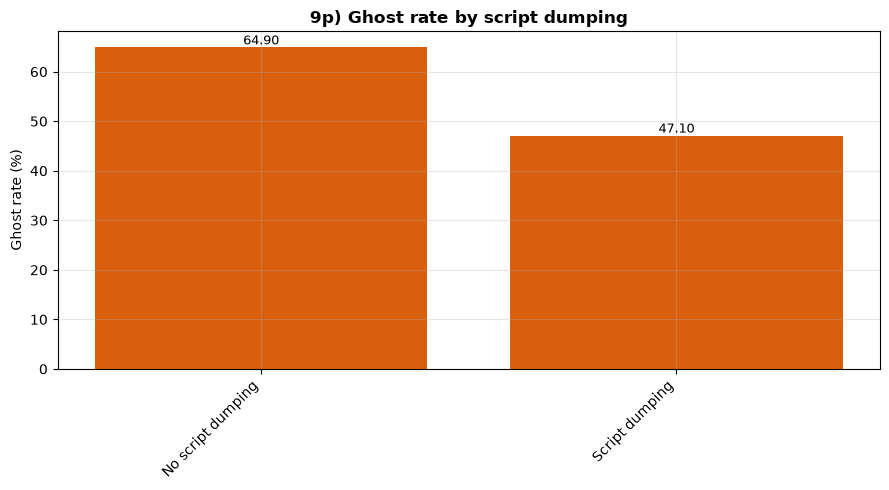

In [30]:
# %%
# --- Pairing: ghost rate by script dumping ---
tmp = df.assign(ghosted=(df["end_mood"] == "Ghosted"))
g = tmp.groupby("script_dumping")["ghosted"].mean().mul(100).round(1)
g.index = g.index.map({True: "Script dumping", False: "No script dumping"})
print("Ghost rate by whether the bot dumped scripts:")
show(g.to_frame("ghost_rate_%"))
plot_mean_bar(g, "9p) Ghost rate by script dumping", "Ghost rate (%)")


%% [markdown]
## 10. `user_intent` — Signal vs. noise

**Measures:** the mix of intents (Genuine Seeker, Passive Listener, Challenger, Troll/Spam, Greeting Only, Muslim Learner…).
**Why it matters:** separates the people who matter most (Genuine Seekers, Conversion Interest) from greetings, trolls and passive listeners — i.e. the *real* size of your addressable audience.
**Pairing (`× is_existing_muslim`):** sanity-checks the data and separates Muslim vs. non-Muslim intent patterns.


User intent distribution:
                       count  percent
user_intent                          
Passive Listener        2798     22.5
Muslim Learner          2438     19.6
Genuine Seeker          2013     16.2
Greeting Only           1925     15.5
Challenger              1546     12.4
Off-Topic User           911      7.3
Troll/Spam               340      2.7
Conversion Interest      262      2.1
Dawah Training           192      1.5
Content Assistance        14      0.1
Minimal/No Engagement      8      0.1
ERROR                      1      0.0



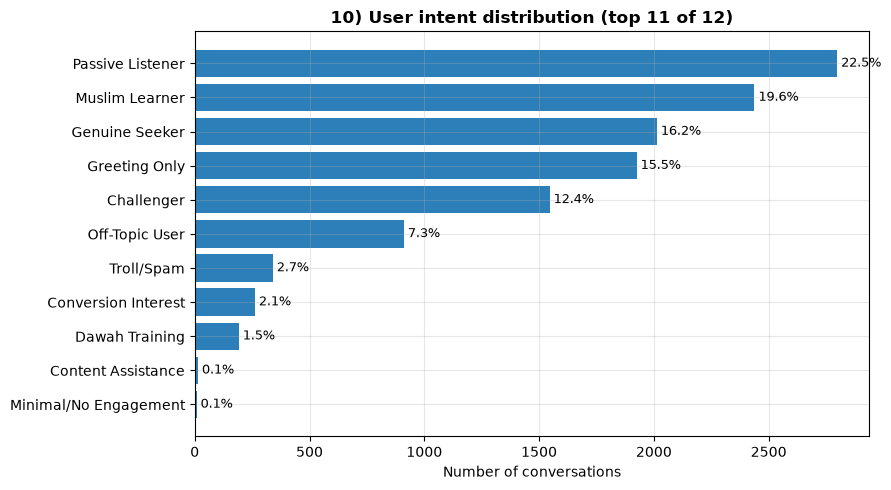

In [50]:

# %%
# --- Main: user intent distribution ---
summary = cat_summary(df["user_intent"])
print("User intent distribution:")
show(summary)
plot_bar(summary, "10) User intent distribution", horizontal=True,top_n=11)


User intent by Muslim / Non-Muslim:
user                   Muslim  Non-Muslim
user_intent                              
Challenger                 53        1493
Content Assistance          5           9
Conversion Interest        16         246
Dawah Training            143          49
ERROR                       0           1
Genuine Seeker              1        2012
Greeting Only             466        1459
Minimal/No Engagement       0           8
Muslim Learner           2438           0
Off-Topic User            384         527
Passive Listener         1084        1714
Troll/Spam                 11         329



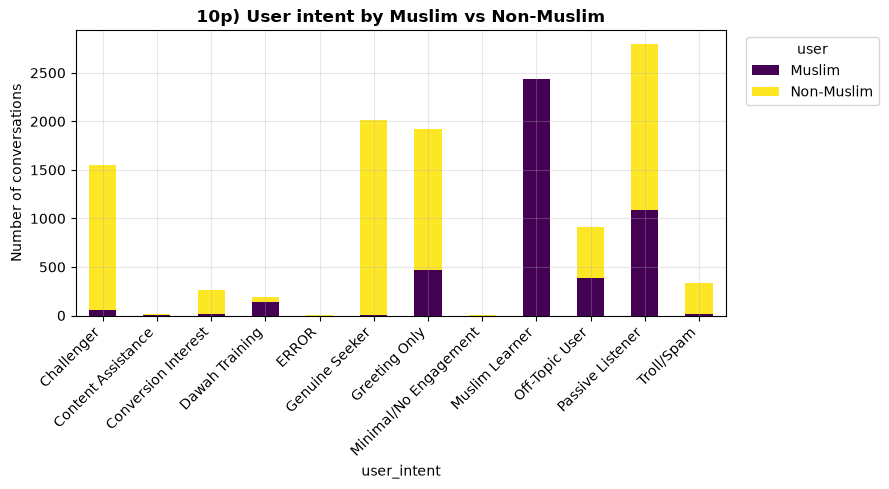

In [32]:
# %%
# --- Pairing: intent x is_existing_muslim ---
ct = pd.crosstab(df["user_intent"],
                 df["is_existing_muslim"].map({True: "Muslim", False: "Non-Muslim"}))
ct.columns.name = "user"
print("User intent by Muslim / Non-Muslim:")
show(ct)
plot_crosstab(ct, "10p) User intent by Muslim vs Non-Muslim", stacked=True)


## 11. `conversion_funnel` — Where are prospects in their journey?

**Measures:** among applicable rows only (non-Muslim da'wah conversations), the mix of Top / Middle / Bottom / Converted / Dropped.
**Why it matters:** your da'wah "sales funnel". Mostly Top + Dropped with an empty middle means the bot makes contact but builds no momentum.
**Pairing (`× suspected_religion`):** whether some groups progress further than others.
⚠️ Only analyze applicable rows, or Muslims / off-topic users corrupt the picture.


Conversion funnel across 5013 applicable conversations (7435 were Not Applicable):
                   count  percent
conversion_funnel                
Top                 2230     44.5
Middle              1727     34.5
Bottom               102      2.0
Converted            146      2.9
Dropped              807     16.1



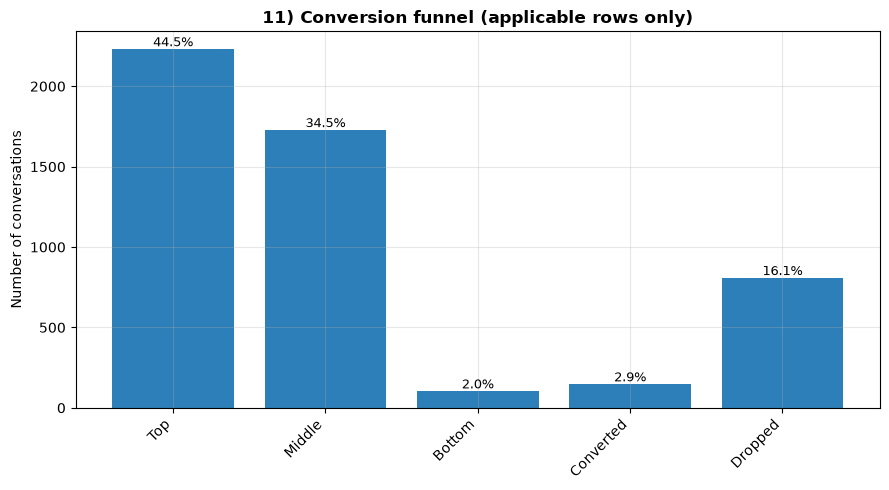

In [33]:
# %%
# --- Main: conversion funnel (applicable rows only) ---
appl = df.dropna(subset=["conversion_funnel"])
order = ["Top", "Middle", "Bottom", "Converted", "Dropped"]
summary = cat_summary(appl["conversion_funnel"]).reindex(
    [s for s in order if s in appl["conversion_funnel"].unique()])
print(f"Conversion funnel across {len(appl)} applicable conversations "
      f"({len(df)-len(appl)} were Not Applicable):")
show(summary)
plot_bar(summary, "11) Conversion funnel (applicable rows only)")


Conversion funnel stage by religion:
suspected_religion  Agnosticism  Atheism  Buddhism  Christianity  ERROR  Hinduism  Irreligion  Islam  Judaism  Other  Sikhism  Unknown
conversion_funnel                                                                                                                     
Bottom                        6        6         4            36      0        17           5      0        0      0        0       28
Converted                     3       12         1            57      0        36           5      1        1      4        0       26
Dropped                       9      109        14           275      0        22          14      0       14     22        0      328
ERROR                         0        0         0             0      1         0           0      0        0      0        0        0
Middle                       91      329        27           866      0        56          43      0       34     45        2      234
Top               

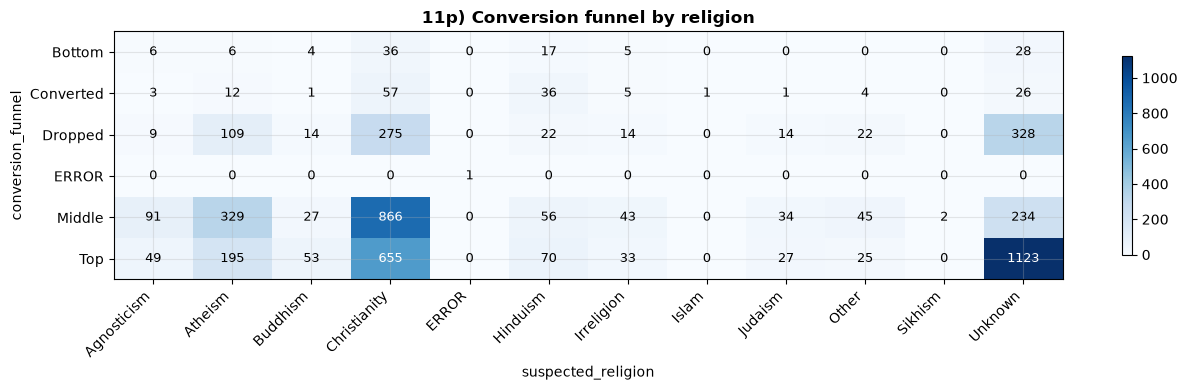

In [44]:
 # --- Pairing: funnel x religion ---
appl = df.dropna(subset=["conversion_funnel"])
ct = pd.crosstab(appl["conversion_funnel"], appl["suspected_religion"])
print("Conversion funnel stage by religion:")
show(ct)
plot_heatmap(ct, "11p) Conversion funnel by religion")


## 12. `script_dumping` — How often does the bot misbehave?

**Measures:** the share of conversations where the bot dumped long pre-written scripts instead of responding.
**Why it matters:** its worst, most damaging habit. As a yes/no flag it's the easiest bot problem to track over time — fix the prompt and this rate should fall.
**Pairing (`× response_quality`):** quantifies the damage — dumped conversations should score visibly lower.


Script-dumping rate:
                   count  percent
bot_behavior                     
No script dumping   8595     69.0
Script dumping      3853     31.0



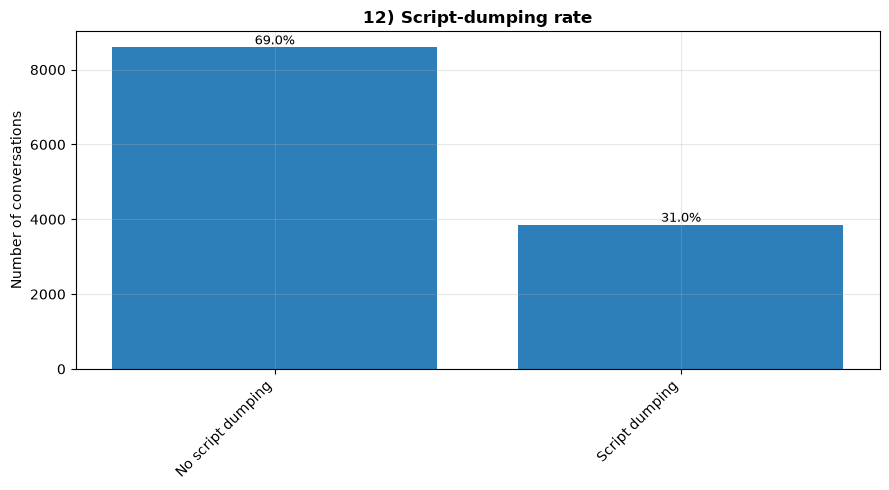

In [45]:
# --- Main: script dumping rate ---
labels = df["script_dumping"].map({True: "Script dumping", False: "No script dumping"})
summary = cat_summary(labels.rename("bot_behavior"))
print("Script-dumping rate:")
show(summary)
plot_bar(summary, "12) Script-dumping rate")

Average response quality by script-dumping:
                   avg_quality     n
script_dumping                      
No script dumping         3.33  8595
Script dumping            2.41  3853



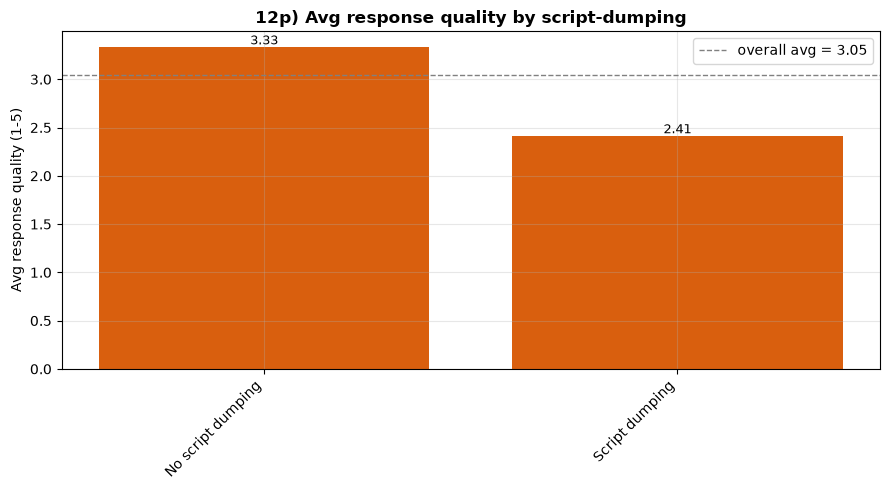

In [34]:
# %%
# --- Pairing: response quality by script dumping ---
g = (df.dropna(subset=["response_quality"])
       .groupby("script_dumping")["response_quality"]
       .agg(avg_quality="mean", n="count").round(2))
g.index = g.index.map({True: "Script dumping", False: "No script dumping"})
print("Average response quality by script-dumping:")
show(g)
plot_mean_bar(g["avg_quality"], "12p) Avg response quality by script-dumping",
              "Avg response quality (1-5)", baseline=df["response_quality"].mean())


## 13. `response_quality` — The bot's report card

**Measures:** distribution of bot-quality scores 1 (broken) → 5 (excellent), plus average & median.
**Why it matters:** the clearest grade for the bot itself (vs. `engagement_score`, which grades the user). Clustering at 2–3 with few 5s = often mediocre, rarely excellent. Tracking the average is the most direct proof your improvements work.
**Pairing (`× conversation_type`):** which types the bot handles well vs. struggles with — pointing to exactly where it needs work.


Response quality distribution:
                  count  percent
response_quality                
0                     2      0.0
1                   795      6.4
2                  2909     23.4
3                  4907     39.4
4                  2600     20.9
5                  1235      9.9

Average = 3.05 | Median = 3.0


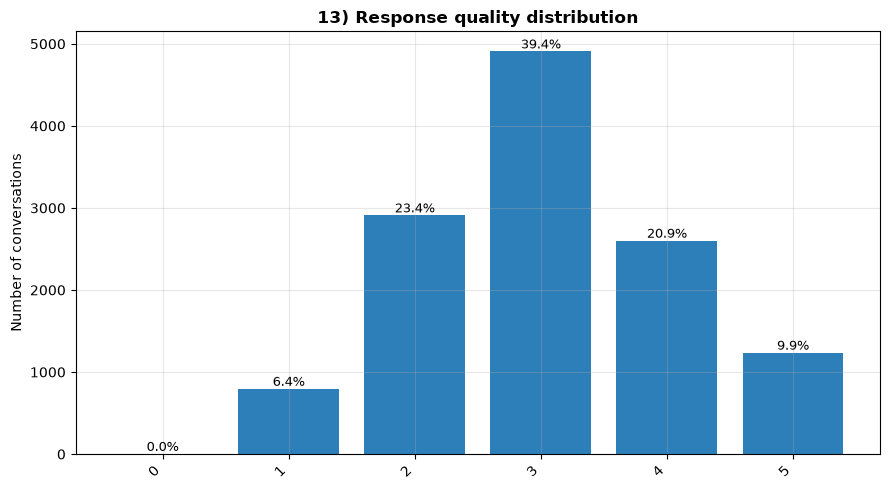

In [35]:
# %%
# --- Main: response quality distribution ---
summary = cat_summary(df["response_quality"]).sort_index()
print("Response quality distribution:")
show(summary)
print(f"Average = {df['response_quality'].mean():.2f} | Median = {df['response_quality'].median():.1f}")
plot_bar(summary, "13) Response quality distribution")


Average response quality by conversation type:
                       avg_quality     n
conversation_type                       
Muslim Learner                 4.0     8
Dawah Training                3.91   912
Content Assistance            3.77   269
Islamic Guidance              3.51  2814
Emotional Support             3.44    54
Theological Debate            3.07  1354
Off-Topic                     3.04   783
Dawah                         2.86  3419
Minimal/No Engagement         2.44  2834
ERROR                          0.0     1



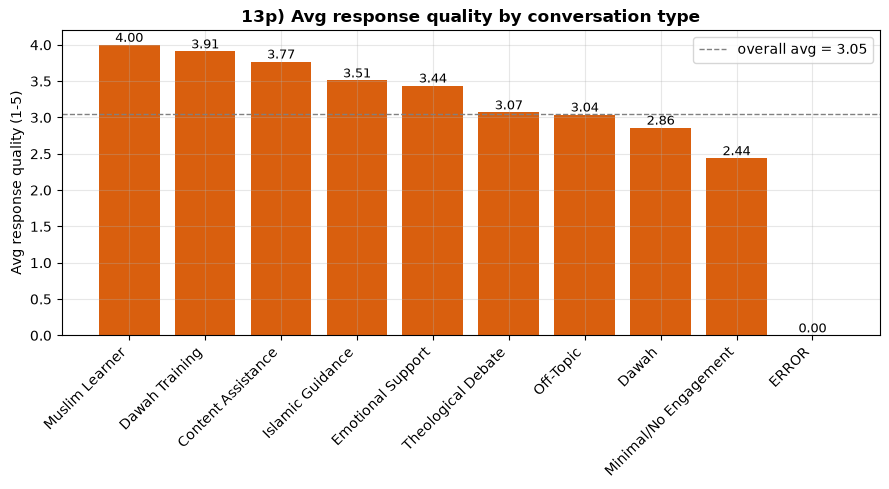

In [36]:
# %%
# --- Pairing: avg response quality per conversation type ---
g = (df.dropna(subset=["conversation_type", "response_quality"])
       .groupby("conversation_type")["response_quality"]
       .agg(avg_quality="mean", n="count").round(2)
       .sort_values("avg_quality", ascending=False))
print("Average response quality by conversation type:")
show(g)
plot_mean_bar(g["avg_quality"], "13p) Avg response quality by conversation type",
              "Avg response quality (1-5)", baseline=df["response_quality"].mean())